Dataset Shape: (200, 7)


,VisitorID,LeadSource,Campaign,Region,Converted,TimeOnSite,PagesVisited
0,1,Instagram,Email Campaign,West,Yes,10,2
1,2,Referral,Email Campaign,East,No,10,4
2,3,LinkedIn,Email Campaign,West,Yes,3,6
3,4,Referral,Summer,East,Yes,1,2
4,5,Referral,Email Campaign,West,No,5,8



================ KPIs ================
Visitors : 200
Leads : 200
Customers : 64
Conversion Rate : 32.00%
Drop-off Rate : 68.00%


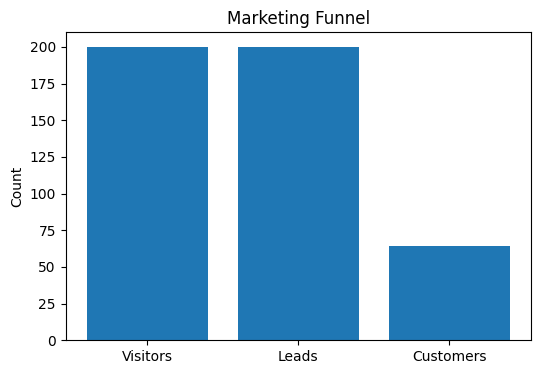

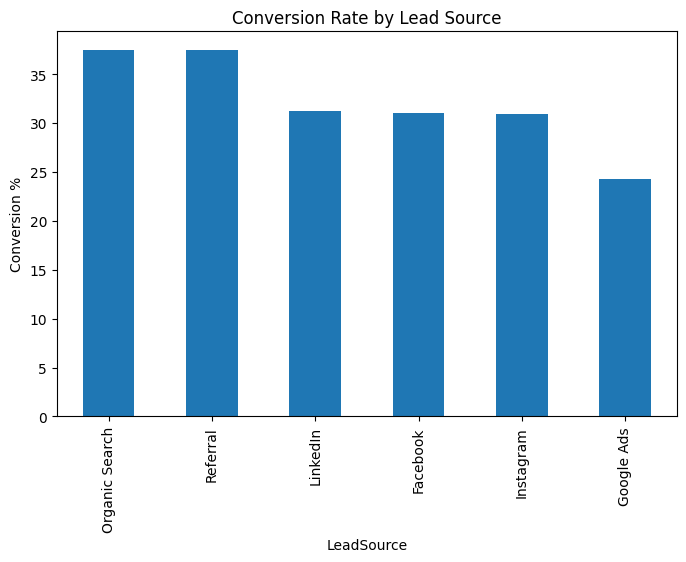


Lead Source Conversion


,Converted
LeadSource,
Organic Search,37.50
Referral,37.50
LinkedIn,31.25
Facebook,31.03
Instagram,30.95
Google Ads,24.24


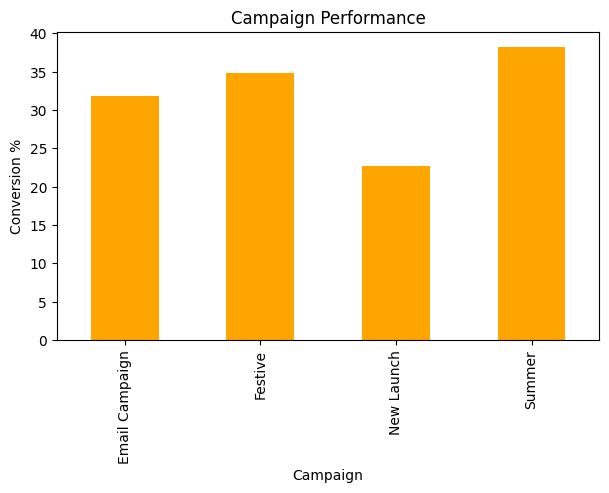

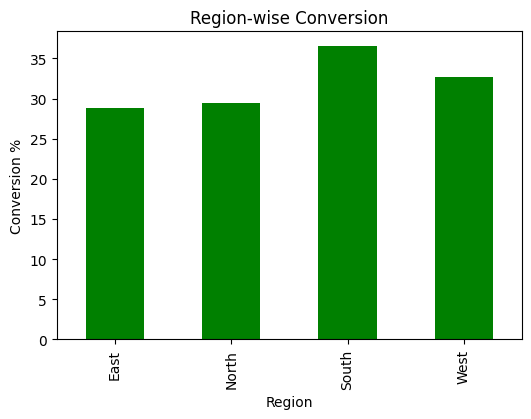

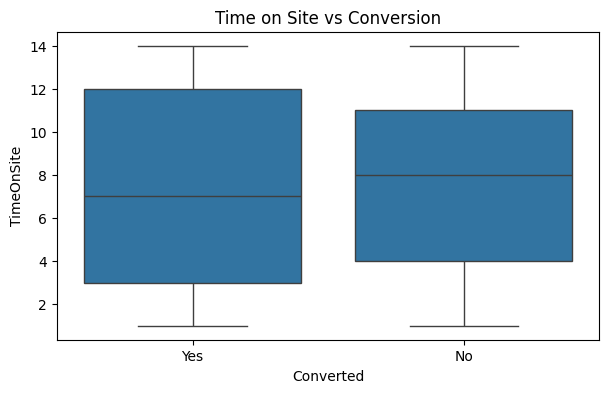

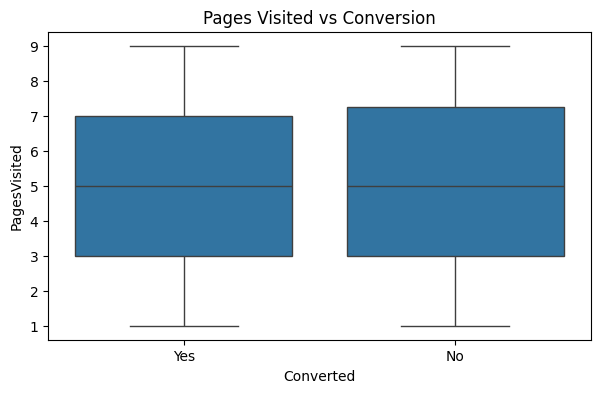


================ BUSINESS INSIGHTS ================
Overall Conversion Rate : 32.00%
Overall Drop-off Rate : 68.00%

Best Lead Source : Organic Search
Highest Conversion : 37.5 %

Best Campaign : Summer
Best Region : South

================ RECOMMENDATIONS ================
1. Increase budget for the highest-converting lead source.
2. Improve underperforming campaigns with A/B testing.
3. Retarget visitors who did not convert.
4. Simplify the signup or registration process.
5. Focus marketing efforts on the best-performing region.
6. Encourage users to spend more time on the website with engaging content.

================ END OF ANALYSIS ================


In [1]:
# ============================================================
# MARKETING FUNNEL ANALYSIS (DATASET CREATED IN CODE)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

# ------------------------------------------------
# Create Sample Dataset
# ------------------------------------------------

n = 200

lead_sources = ["Google Ads","Facebook","LinkedIn","Instagram","Referral","Organic Search"]
campaigns = ["Summer","Festive","New Launch","Email Campaign"]
regions = ["North","South","East","West"]

df = pd.DataFrame({
    "VisitorID": range(1, n+1),
    "LeadSource": np.random.choice(lead_sources, n),
    "Campaign": np.random.choice(campaigns, n),
    "Region": np.random.choice(regions, n),
    "Converted": np.random.choice(["Yes","No"], n, p=[0.35,0.65]),
    "TimeOnSite": np.random.randint(1,15,n),
    "PagesVisited": np.random.randint(1,10,n)
})

print("Dataset Shape:", df.shape)
display(df.head())

# ------------------------------------------------
# KPIs
# ------------------------------------------------

total_visitors = len(df)
leads = total_visitors
customers = (df["Converted"]=="Yes").sum()

conversion_rate = customers / total_visitors * 100
drop_off = 100 - conversion_rate

print("\n================ KPIs ================")
print("Visitors :", total_visitors)
print("Leads :", leads)
print("Customers :", customers)
print(f"Conversion Rate : {conversion_rate:.2f}%")
print(f"Drop-off Rate : {drop_off:.2f}%")

# ------------------------------------------------
# Funnel Chart
# ------------------------------------------------

plt.figure(figsize=(6,4))
plt.bar(["Visitors","Leads","Customers"],
        [total_visitors, leads, customers])
plt.title("Marketing Funnel")
plt.ylabel("Count")
plt.show()

# ------------------------------------------------
# Lead Source Conversion
# ------------------------------------------------

conversion = (
    df.groupby("LeadSource")["Converted"]
      .apply(lambda x: (x=="Yes").mean()*100)
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))
conversion.plot(kind="bar")
plt.ylabel("Conversion %")
plt.title("Conversion Rate by Lead Source")
plt.show()

print("\nLead Source Conversion")
display(conversion.round(2))

# ------------------------------------------------
# Campaign Performance
# ------------------------------------------------

campaign = (
    df.groupby("Campaign")["Converted"]
      .apply(lambda x:(x=="Yes").mean()*100)
)

plt.figure(figsize=(7,4))
campaign.plot(kind="bar", color="orange")
plt.ylabel("Conversion %")
plt.title("Campaign Performance")
plt.show()

# ------------------------------------------------
# Region Performance
# ------------------------------------------------

region = (
    df.groupby("Region")["Converted"]
      .apply(lambda x:(x=="Yes").mean()*100)
)

plt.figure(figsize=(6,4))
region.plot(kind="bar", color="green")
plt.ylabel("Conversion %")
plt.title("Region-wise Conversion")
plt.show()

# ------------------------------------------------
# Time on Site
# ------------------------------------------------

plt.figure(figsize=(7,4))
sns.boxplot(data=df, x="Converted", y="TimeOnSite")
plt.title("Time on Site vs Conversion")
plt.show()

# ------------------------------------------------
# Pages Visited
# ------------------------------------------------

plt.figure(figsize=(7,4))
sns.boxplot(data=df, x="Converted", y="PagesVisited")
plt.title("Pages Visited vs Conversion")
plt.show()

# ------------------------------------------------
# Business Insights
# ------------------------------------------------

print("\n================ BUSINESS INSIGHTS ================")

print(f"Overall Conversion Rate : {conversion_rate:.2f}%")
print(f"Overall Drop-off Rate : {drop_off:.2f}%")

print("\nBest Lead Source :", conversion.idxmax())
print("Highest Conversion :", round(conversion.max(),2), "%")

print("\nBest Campaign :", campaign.idxmax())
print("Best Region :", region.idxmax())

print("\n================ RECOMMENDATIONS ================")

print("1. Increase budget for the highest-converting lead source.")
print("2. Improve underperforming campaigns with A/B testing.")
print("3. Retarget visitors who did not convert.")
print("4. Simplify the signup or registration process.")
print("5. Focus marketing efforts on the best-performing region.")
print("6. Encourage users to spend more time on the website with engaging content.")

print("\n================ END OF ANALYSIS ================")